

Notebook EDA - Olist Order Payments Dataset
Phân tích thám hiểm dữ liệu thanh toán của Olist.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
# Cấu hình hiển thị
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [37]:
payment_data = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")
orders = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")

In [4]:
# Thông tin tổng quan về các cột
payment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [5]:
display(payment_data.head())
print(payment_data.shape)
payment_data.dtypes

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


(103886, 5)


order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

In [6]:
#  Kiểm tra dữ liệu thiếu và trùng lặp
missing = payment_data.isnull().sum()
print("Giá trị thiếu theo cột:\n", missing[missing > 0])
duplicates = payment_data.duplicated().sum()
print(f"\nSố lượng bản ghi trùng lặp hoàn toàn: {duplicates}")

Giá trị thiếu theo cột:
 Series([], dtype: int64)

Số lượng bản ghi trùng lặp hoàn toàn: 0


In [7]:
# Thống kê mô tả các biến số
payment_data[['payment_value', 'payment_installments']].describe()

,payment_value,payment_installments
count,103886.00,103886.00
mean,154.10,2.85
std,217.49,2.69
min,0.00,0.00
25%,56.79,1.00
50%,100.00,1.00
75%,171.84,4.00
max,13664.08,24.00


##### **Nhận xét sơ bộ:**
###### - `payment_value` trung bình ≈ 154, độ lệch chuẩn lớn (272) → có nhiều giao dịch giá trị cao.
###### - `payment_installments` trung bình ≈ 1.42, tối đa 24 tháng.
###### - `payment_sequential` trung bình ≈ 1.14 → hầu hết đơn hàng chỉ có 1 phương thức thanh toán.


#### Phân tích phương thức thanh toán (payment_type)

In [8]:
# Phân phối các loại thanh toán
payment_type_counts = payment_data['payment_type'].value_counts()
payment_type_pct = 100 * payment_type_counts / len(payment_data)

payment_summary = pd.DataFrame({
    'Số lượng': payment_type_counts,
    'Tỉ lệ (%)': payment_type_pct
})
print(payment_summary)


              Số lượng  Tỉ lệ (%)
payment_type                     
credit_card      76795      73.92
boleto           19784      19.04
voucher           5775       5.56
debit_card        1529       1.47
not_defined          3       0.00


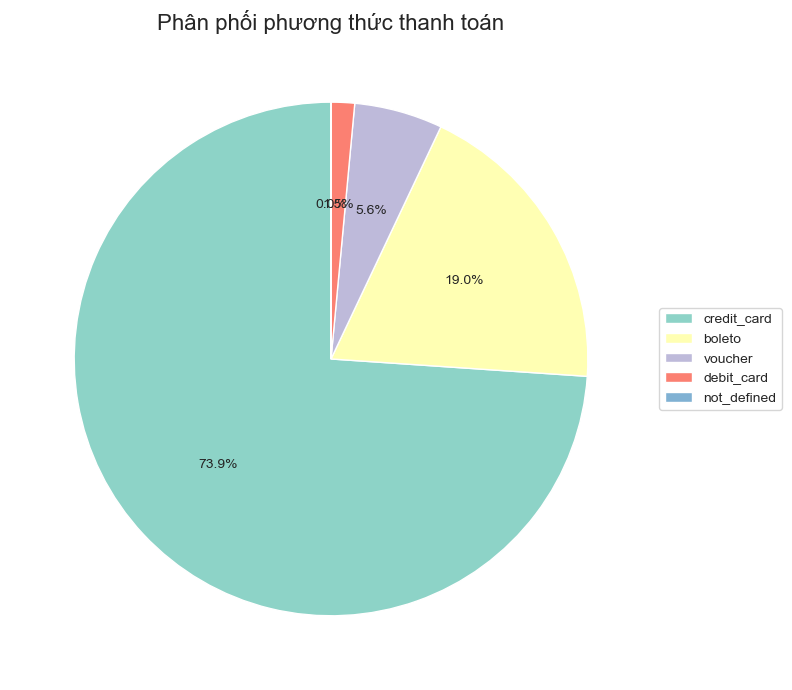

In [14]:
# Biểu đồ tròn
plt.figure(figsize=(8,8))

plt.pie(
    payment_type_counts,
    labels=None,              
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set3'),
    wedgeprops={'edgecolor':'white'}
)

plt.legend(
    payment_type_counts.index,
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Phân phối phương thức thanh toán', fontsize=16)
plt.tight_layout()
plt.show()


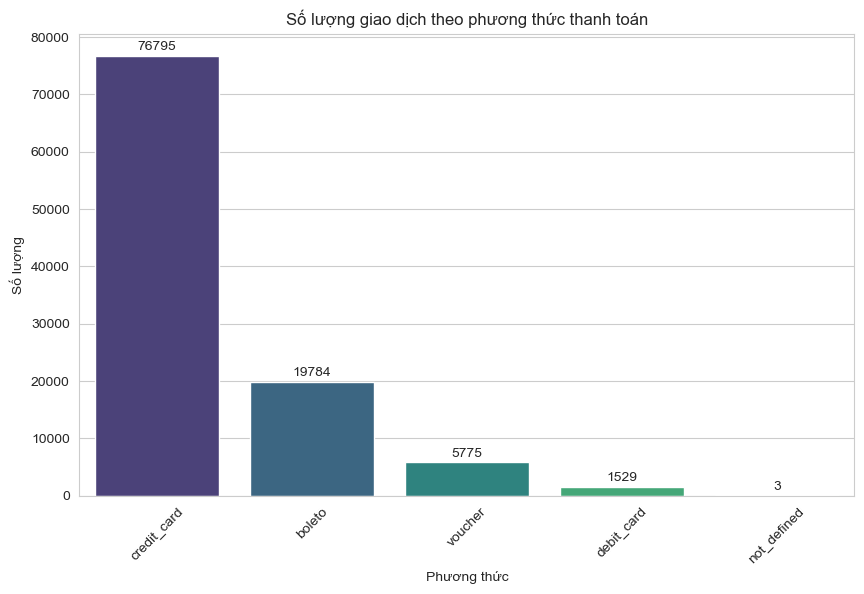

In [17]:
# Biểu đồ cột
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_type_counts.index, y=payment_type_counts.values,hue=payment_type_counts.index, palette='viridis',legend=False)
plt.title('Số lượng giao dịch theo phương thức thanh toán')
plt.xlabel('Phương thức')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
for i, v in enumerate(payment_type_counts.values):
    plt.text(i, v + 500, str(v), ha='center', va='bottom')
plt.show()

#### Nhận xét: Credit Card chiếm ưu thế tuyệt đối (~75%), tiếp theo là boleto (~20%), voucher và debit card chiếm tỉ lệ nhỏ.

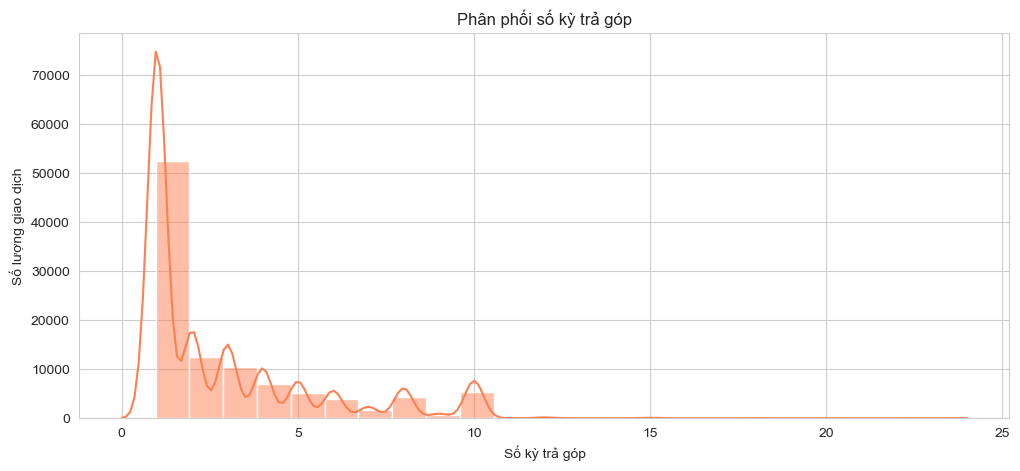

In [20]:
# Phân tích số kỳ trả góp (installments)
# Phân phối số kỳ trả góp
plt.figure(figsize=(12, 5))
sns.histplot(payment_data['payment_installments'], bins=25, kde=True, color='coral')
plt.title('Phân phối số kỳ trả góp')
plt.xlabel('Số kỳ trả góp')
plt.ylabel('Số lượng giao dịch')
plt.show()

In [21]:
# Chi tiết các giá trị installments
installment_counts = payment_data['payment_installments'].value_counts().sort_index()
print("Số lượng giao dịch theo số kỳ trả góp:")
print(installment_counts.head(10))

Số lượng giao dịch theo số kỳ trả góp:
payment_installments
0        2
1    52546
2    12413
3    10461
4     7098
5     5239
6     3920
7     1626
8     4268
9      644
Name: count, dtype: int64


In [22]:
# Tỉ lệ thanh toán một lần (installments = 1)
one_time_pct = 100 * (payment_data['payment_installments'] == 1).sum() / len(payment_data)
print(f"Tỉ lệ thanh toán một lần (không trả góp): {one_time_pct:.2f}%")


Tỉ lệ thanh toán một lần (không trả góp): 50.58%


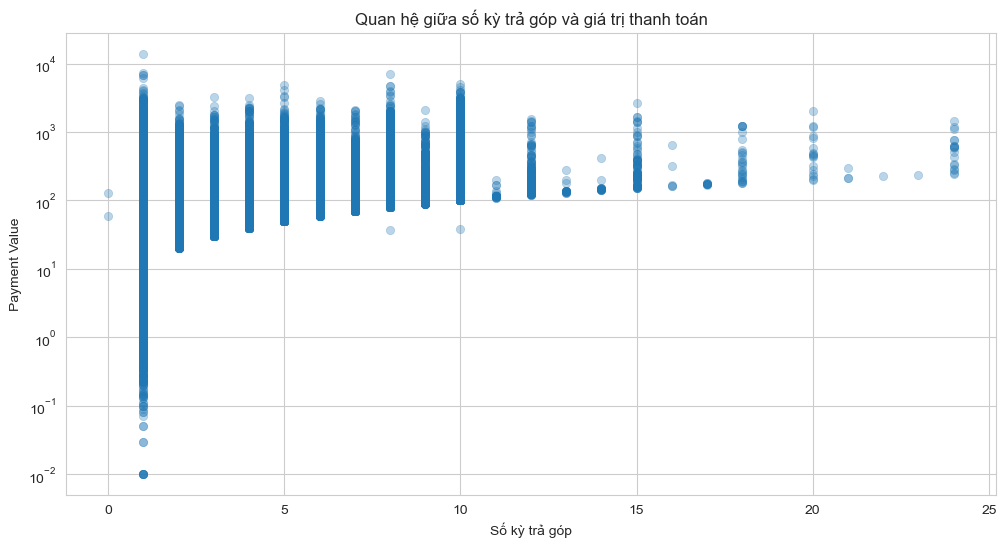

In [23]:
# Quan hệ giữa giá trị và số kỳ trả góp
# Scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=payment_data, x='payment_installments', y='payment_value', alpha=0.3, edgecolor=None)
plt.title('Quan hệ giữa số kỳ trả góp và giá trị thanh toán')
plt.xlabel('Số kỳ trả góp')
plt.ylabel('Payment Value')
plt.yscale('log')
plt.show()

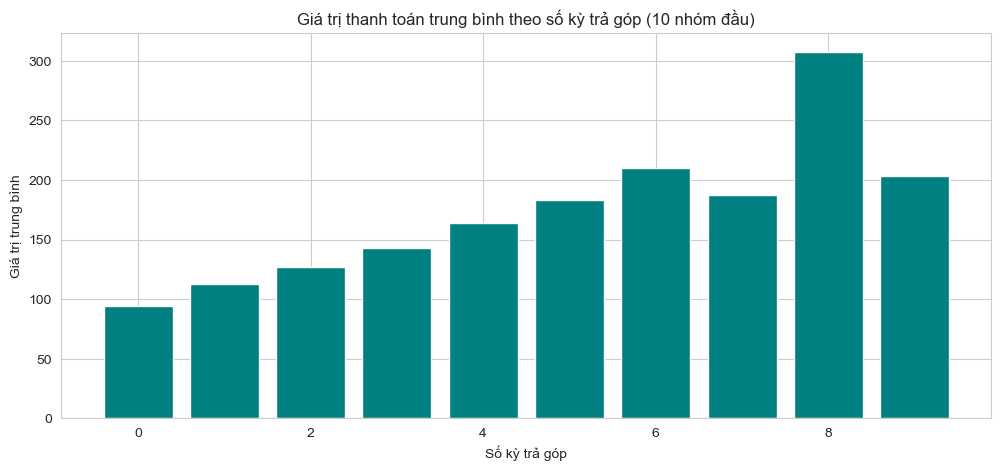

In [24]:
# Giá trị trung bình theo số kỳ trả góp
avg_value_by_install = payment_data.groupby('payment_installments')['payment_value'].mean().reset_index()
plt.figure(figsize=(12, 5))
plt.bar(avg_value_by_install['payment_installments'].head(10), 
        avg_value_by_install['payment_value'].head(10), color='teal')
plt.title('Giá trị thanh toán trung bình theo số kỳ trả góp (10 nhóm đầu)')
plt.xlabel('Số kỳ trả góp')
plt.ylabel('Giá trị trung bình')
plt.show()


##### Nhận xét: Giá trị thanh toán càng lớn thì số kỳ trả góp càng nhiều (xu hướng rõ rệt).

Số lượng giao dịch theo payment_sequential:
payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
16        6
17        6
18        6
19        6
20        4
21        4
22        3
23        2
24        2
25        2
26        2
27        1
28        1
29        1
Name: count, dtype: int64


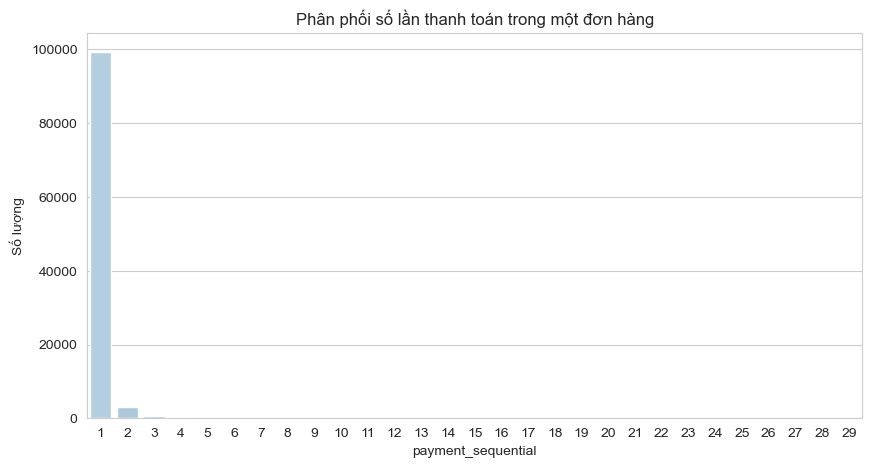

In [27]:
# Phân tích sequential (thứ tự thanh toán trong đơn hàng)
# Phân phối số lần thanh toán trong một đơn hàng
seq_counts = payment_data['payment_sequential'].value_counts().sort_index()
print("Số lượng giao dịch theo payment_sequential:")
print(seq_counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=seq_counts.index, y=seq_counts.values, hue=seq_counts.index, palette='Blues_d', legend=False)
plt.title('Phân phối số lần thanh toán trong một đơn hàng')
plt.xlabel('payment_sequential')
plt.ylabel('Số lượng')
plt.show()


#### Nhận xét: Phần lớn đơn hàng chỉ có 1 lần thanh toán. Một số ít có 2 hoặc nhiều hơn (có thể do thanh toán bổ sung hoặc chia nhỏ).

In [28]:
#  Phân tích đơn hàng có nhiều phương thức thanh toán
# Đếm số phương thức thanh toán duy nhất cho mỗi order_id
methods_per_order = payment_data.groupby('order_id')['payment_type'].nunique().reset_index()
methods_per_order.columns = ['order_id', 'n_payment_methods']

print(f"Số đơn hàng sử dụng 1 phương thức: {(methods_per_order['n_payment_methods'] == 1).sum()}")
print(f"Số đơn hàng sử dụng >1 phương thức: {(methods_per_order['n_payment_methods'] > 1).sum()}")



Số đơn hàng sử dụng 1 phương thức: 97194
Số đơn hàng sử dụng >1 phương thức: 2246


In [29]:
# Ví dụ một số đơn hàng có nhiều phương thức thanh toán
multi_method_orders = methods_per_order[methods_per_order['n_payment_methods'] > 1].head(10)
print("Các đơn hàng có nhiều phương thức thanh toán:")
print(multi_method_orders)

Các đơn hàng có nhiều phương thức thanh toán:
                             order_id  n_payment_methods
36   0016dfedd97fc2950e388d2971d718c7                  2
215  009ac365164f8e06f59d18a08045f6c4                  2
258  00b4a910f64f24dbcac04fe54088a443                  2
274  00bd50cdd31bd22e9081e6e2d5b3577b                  2
282  00c405bd71187154a7846862f585a9d4                  2
295  00c95282163553a982f38481f9488481                  2
338  00e6bc6b166eb28b4502c1cad4457248                  2
464  013037c3f1773cc8fdbaf8ff54d8013b                  2
806  0218c7a4fb8d5b1bd22c82b783b8359c                  2
939  02725851051698269253f0823e7824b6                  2


In [30]:
# Hiển thị chi tiết một đơn hàng cụ thể
if len(multi_method_orders) > 0:
    example_order = multi_method_orders.iloc[0]['order_id']
    print(f"\nChi tiết đơn hàng {example_order}:")
    print(payment_data[payment_data['order_id'] == example_order])



Chi tiết đơn hàng 0016dfedd97fc2950e388d2971d718c7:
                               order_id  payment_sequential payment_type  \
80856  0016dfedd97fc2950e388d2971d718c7                   2      voucher   
89575  0016dfedd97fc2950e388d2971d718c7                   1  credit_card   

       payment_installments  payment_value  
80856                     1          17.92  
89575                     5          52.63  


In [31]:
#  Top 10% giao dịch giá trị cao
# Xác định ngưỡng 90%
threshold_90 = payment_data['payment_value'].quantile(0.9)
high_value = payment_data[payment_data['payment_value'] >= threshold_90]

print(f"Ngưỡng 90%: {threshold_90:.2f}")
print(f"Số giao dịch giá trị cao (top 10%): {len(high_value)} ({100*len(high_value)/len(payment_data):.2f}%)")

Ngưỡng 90%: 297.27
Số giao dịch giá trị cao (top 10%): 10390 (10.00%)


In [32]:
# Phân tích top 10% theo payment_type
high_value_by_type = high_value['payment_type'].value_counts()
print("Phân bố phương thức thanh toán trong top 10% giao dịch:")
print(high_value_by_type)

Phân bố phương thức thanh toán trong top 10% giao dịch:
payment_type
credit_card    8469
boleto         1684
voucher         124
debit_card      113
Name: count, dtype: int64


In [33]:
# So sánh installments giữa top 10% và phần còn lại
high_install = high_value['payment_installments'].mean()
low_install = payment_data[payment_data['payment_value'] < threshold_90]['payment_installments'].mean()
print(f"Số kỳ trả góp trung bình - Top 10%: {high_install:.2f}")
print(f"Số kỳ trả góp trung bình - 90% còn lại: {low_install:.2f}")

Số kỳ trả góp trung bình - Top 10%: 5.33
Số kỳ trả góp trung bình - 90% còn lại: 2.58


##### Nhận xét: Các giao dịch giá trị cao có xu hướng trả góp nhiều hơn.

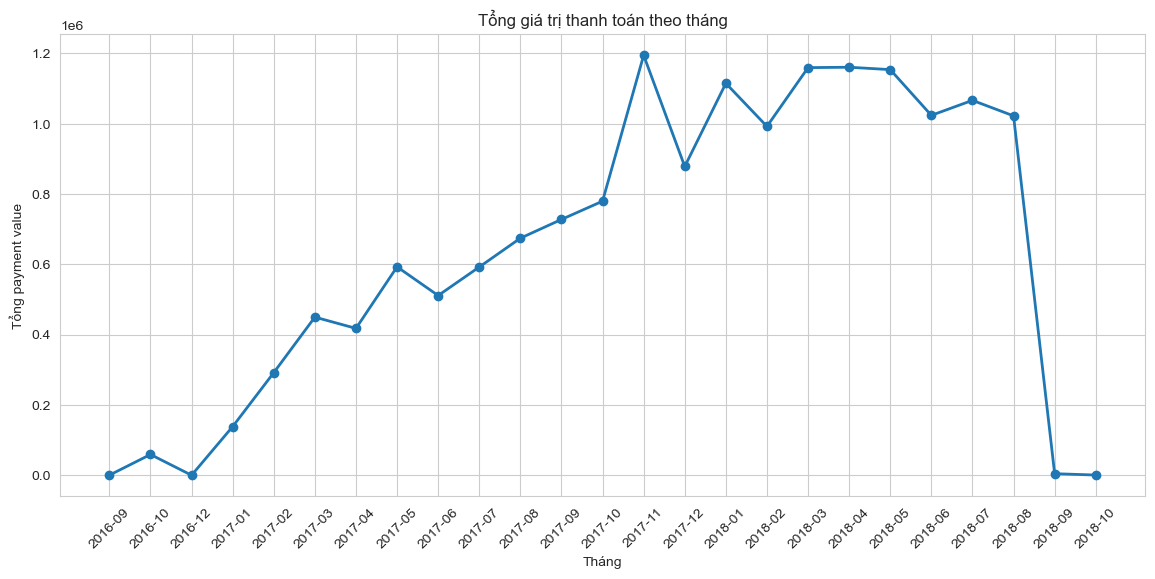

In [38]:
#  Kết hợp với dữ liệu đơn hàng (optional)
# Đọc file orders để có thêm thông tin về thời gian 
try:
    orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
    
    # Merge payments với orders
    merged = payment_data.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
    
    # Phân tích theo thời gian
    merged['year_month'] = merged['order_purchase_timestamp'].dt.to_period('M')
    monthly_value = merged.groupby('year_month')['payment_value'].sum().reset_index()
    
    plt.figure(figsize=(14, 6))
    plt.plot(monthly_value['year_month'].astype(str), monthly_value['payment_value'], marker='o', linewidth=2)
    plt.title('Tổng giá trị thanh toán theo tháng')
    plt.xlabel('Tháng')
    plt.ylabel('Tổng payment value')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
    
except FileNotFoundError:
    print("Không tìm thấy file olist_orders_dataset.csv để phân tích thời gian.")

### Kết luận và đề xuất
#### **Tổng kết từ EDA Payment:**
##### - Credit Card là phương thức thanh toán phổ biến nhất (~75%).
##### - Hơn 80% giao dịch được thanh toán một lần (không trả góp).
##### - Giá trị thanh toán càng cao, số kỳ trả góp càng nhiều.
##### - Phần lớn đơn hàng chỉ sử dụng 1 phương thức thanh toán duy nhất.
#
#### **Hướng phân tích tiếp theo:**
##### - Phân tích hành vi trả góp theo nhóm khách hàng.
##### - Xây dựng mô hình dự đoán rủi ro thanh toán dựa trên payment_type và installments.
##### - Kết hợp với dữ liệu đánh giá để xem phương thức thanh toán có ảnh hưởng đến review score không.